# **EDA & NLP Analysis — electricalworld.com | Electronics & Technology**

### **Libraries**

In [1]:
import re
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import unicodedata
import logging
from typing import Optional

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from transformers import pipeline as hf_pipeline

# Own libraries
import sys
if '../src' not in sys.path:
    sys.path.append('../src')
import cleaning
import eda
import nlp

c:\Users\HP\Desktop\Master\7. DL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Sector & Company Configuration**

In [2]:
TARGET = "electricalworld.com"
CAT = "Electronics & Technology"

### **Data Load**

#### **Companies Dataset**
- This dataset is going to be loaded just to visualize which portion of the total each `category` represents.
- In this dataset all companies have the maximum of a **100** reviews.
- The values of the columns: `median_stars`, `media_stars`, `std_stars`, are the same for all countries, so no additional information is given.

In [3]:
company_category = pd.read_excel("../datasets/emp_100_reviews.xlsx")
company_category.head()

,category,company,n_reviews,median_stars,media_stars,std_stars
0,Animals & Pets,gardenbird.co.uk,100,3,3,1.421338
1,Restaurants & Bars,www.brewersfayre.co.uk,100,3,3,1.421338
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338
3,Restaurants & Bars,nonnatonda.co.uk,100,3,3,1.421338
4,Restaurants & Bars,planthood.co.uk,100,3,3,1.421338


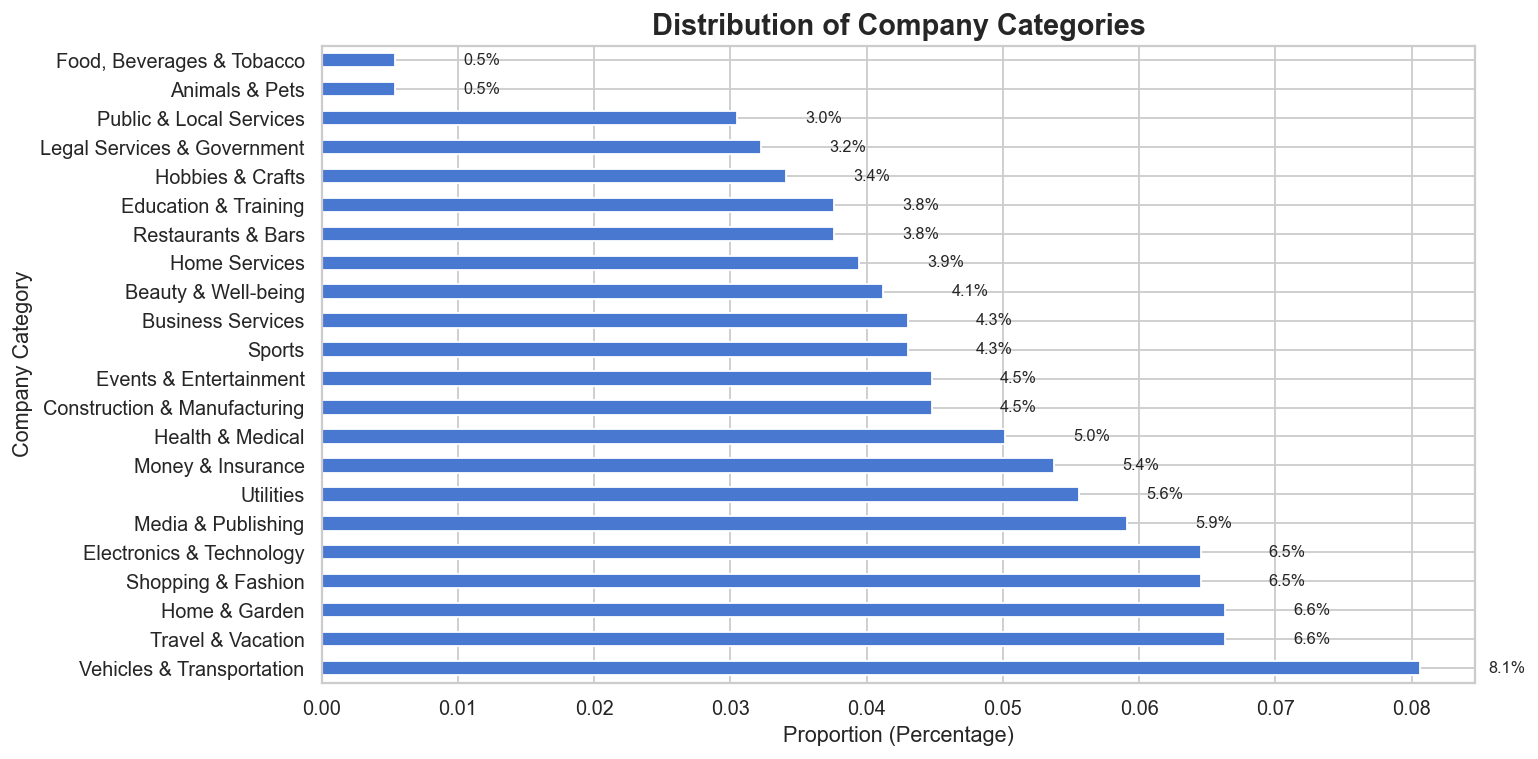

In [4]:
# Get the normalized value counts
category_props = company_category['category'].value_counts(normalize=True)

# Create horizontal barplot
plt.figure(figsize=(12, 6))

# Create horizontal bars
category_props.plot(kind='barh')

# Add titles and labels
plt.title('Distribution of Company Categories', fontsize=16, fontweight='bold')
plt.xlabel('Proportion (Percentage)', fontsize=12)
plt.ylabel('Company Category', fontsize=12)

# Add percentage labels on bars
for i, (category, value) in enumerate(category_props.items()):
    plt.text(value + 0.005, i, f'{value:.1%}', 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

For this project we are going to work with a company of the `Electronics & Technology` category. However the procedure followed is going to be exactly the same for all categories.

Now let's see the companies of this category that have a **100 reviews** 

In [5]:
company_category.loc[company_category['category']==CAT, 'company'].unique()

<ArrowStringArray>
[                 'backmarket.co.uk',             'hotpointservice.co.uk',
                     'belling.co.uk',                         'bopdj.com',
               'directvacuums.co.uk',               'electricalworld.com',
                      'giffgaff.com',                   'go-assist.co.uk',
                       'gtech.co.uk',                      'hughes.co.uk',
                   'www.tayna.co.uk',                'www.mrmemory.co.uk',
              'www.partmaster.co.uk',              'www.petertyson.co.uk',
              'www.richersounds.com', 'www.sevenoakssoundandvision.co.uk',
             'www.sonicdirect.co.uk',                     'www.vax.co.uk',
                 'mobiletopup.co.uk',         'www.markselectrical.co.uk',
                'www.lcegroup.co.uk',                   'www.jessops.com',
                'www.idmobile.co.uk',                  'www.hivehome.com',
                   'www.ghdhair.com',                 'www.espares.co.uk',
      

#### **Reviews Dataset**

In [6]:
df = pd.read_csv("../datasets/trustpilot-reviews-123k.csv")
df.head()
#df[df['category']==CAT].head()

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


Quick ``title`` and ``review`` column check

In [7]:
# Display each review one by one
for idx, row in df.loc[df['company']=='electricalworld.com', ['title', 'review']].iterrows():
    print(f"\n{'='*50}")
    print(f"Title: {row['title']}")
    print(f"Review: {row['review']}")
    print(f"{'='*50}")


Title: Christmas Lights Success
Review: Tried everywhere to get a specific set of Christmas Lights to match the other six sets we had around the windows.  Thankfully Electrical World had them in stock and at a much better price than any of the other stockists we had looked at.  Prompt delivery, item well packaged and exactly what we were after!  Thank you!

Title: Product was as expected and great value…
Review: Product was as expected and great value for money. Nice silky soft furry cover. I ordered 6 in total 4 with covers and 2 without covers. Given to various family members who were pleased and grateful as just in time as weather had turned a lot colder. Packaged well. I can honestly and easily recommend.

Title: Great Company and Service
Review: Great Web site, easy to order, good communication , quick delivery and very fair prices. Will use this company again. Product well wrapped snd as described.

Title: I had great experience shopping with…
Review: I had great experience shop

All reviews are in english, otherwise we should select an NLP model suitable for mutilanguage.\
With the next cleaning function we are going to remove:
 - Remove: URLs, HTML code, emails, special characters
 - Normalize: White spaces, new lines, unicode characters (é --> e)

In [8]:
df_clean = cleaning.clean_reviews_by_category(df, CAT)
df_clean.head()

2026-04-17 16:38:28,985 [INFO] Filtering to category: 'Electronics & Technology' ...
2026-04-17 16:38:28,996 [INFO]   → 5,596 rows found across 69 companies.
2026-04-17 16:38:28,997 [INFO] Cleaning text columns: ['title', 'review', 'description'] ...
2026-04-17 16:38:29,117 [INFO]  ✓ 'title'
2026-04-17 16:38:29,606 [INFO]  ✓ 'review'
2026-04-17 16:38:30,542 [INFO]  ✓ 'description'
2026-04-17 16:38:30,542 [INFO] Cleaning complete.


,category,company,description,title,review,stars
0,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
1,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds...,Great service from the Richer Sounds team at S...,5
2,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative...,Wanted a TV for an 84 year old relative whos s...,5
3,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
4,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [9]:
df['stars'].describe()

count    123181.000000
mean          3.182658
std           1.470769
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           5.000000
Name: stars, dtype: float64

## **1. EDA — Sector Overview**

Once the set of reviews for the chosen sector has been cleaned, we can proceed with the exploratory data analysis

In [10]:
print(eda.dataset_overview.__doc__)
eda.dataset_overview(df_clean);


    Print a quick structural summary of the cleaned category DataFrame.

    Shows shape, number of companies, star distribution, and basic
    null/empty counts for the three key columns.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame for a single category.

    Returns
    -------
    pd.DataFrame
        Summary table (also printed to stdout).
    
  DATASET OVERVIEW
  Total reviews      : 5,596
  Unique companies   : 69
  Star range         : 1 – 5
  Avg stars (global) : 3.17

        nulls  empty_strings
column                      
title       0              0
review      0              0
stars       0              0


Next with the function `add_length_features` we add the following information at **Review Level**:
- title_char_len   : number of characters in title
- title_word_count : number of words in title
- review_char_len  : number of characters in review
- review_word_count: number of words in review

With this extended dataframe: **df_feat** and the function `company_stats` we make a **Company level** dataframe, adding:
- avg_stars        : mean star rating
- pct_positive     : % reviews with stars >= 4
- pct_neutral      : % reviews with stars == 3
- pct_negative     : % reviews with stars <= 2
- review_word_count: mean review word count (all reviews)
- wc_positive      : mean word count of positive reviews (stars>=4)
- wc_neutral       : mean word count of neutral reviews (stars==3)
- wc_negative      : mean word count of negative reviews (stars<=2)
- review_count     : total number of reviews


In [11]:
df_feat = eda.add_length_features(df_clean)
display(df_feat)
stats = eda.company_stats(df_feat)
display(stats)

print(f"\n  {len(stats)} companies found. Stats summary:")
print(stats.describe().round(2).to_string())


,category,company,description,title,review,stars,title_char_len,title_word_count,review_char_len,review_word_count
0,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5,7,2,407,69
1,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds...,Great service from the Richer Sounds team at S...,5,35,5,343,63
2,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative...,Wanted a TV for an 84 year old relative whos s...,5,42,9,282,54
3,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5,41,6,308,52
4,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5,46,7,361,65
...,...,...,...,...,...,...,...,...,...,...
5591,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Synthesia braucht Stunden um ein einfaches 1 m...,"Du erstellst ein Video auf synthesia.io1,03 mi...",1,67,10,3561,580
5592,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,False advertising and poor client experience,The videos are good but the client experience ...,1,44,6,351,56
5593,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Unusable Service and a Refund Policy Thats a R...,My experience with Synthesia has been nothing ...,1,92,14,775,123
5594,Electronics & Technology,synthesia.io,Synthesia is the world's 1 AI video communicat...,Beware No-Refund Policy and Unusable App Features,Ive had a frustrating experience with Synthesi...,1,49,7,838,131


,avg_stars,pct_positive,pct_neutral,pct_negative,avg_review_words,avg_title_words,review_word_count,wc_positive,wc_neutral,wc_negative,review_count
company,,,,,,,,,,,
brokenfones.com,5.00,100.00,0.00,0.00,33.40,5.00,33.40,33.40,0.00,0.00,20
licensel.com,4.86,100.00,0.00,0.00,14.64,3.55,14.64,14.64,0.00,0.00,22
pcrepairscheshire.co.uk,4.83,100.00,0.00,0.00,40.04,3.92,40.04,40.04,0.00,0.00,24
wildviewcameras.co.uk,4.77,100.00,0.00,0.00,39.88,3.92,39.88,39.88,0.00,0.00,26
techformusic.co.uk,4.67,100.00,0.00,0.00,41.60,4.20,41.60,41.60,0.00,0.00,30
...,...,...,...,...,...,...,...,...,...,...,...
www.richersounds.com,3.00,40.00,20.00,40.00,78.02,6.08,78.02,67.88,80.65,86.85,100
www.yourspares.co.uk,3.00,40.40,19.19,40.40,47.59,5.20,47.59,32.15,63.84,55.30,99
juicebitz.co.uk,2.99,39.39,20.20,40.40,66.17,5.67,66.17,47.05,82.60,76.60,99



  69 companies found. Stats summary:
       avg_stars  pct_positive  pct_neutral  pct_negative  avg_review_words  avg_title_words  review_word_count  wc_positive  wc_neutral  wc_negative  review_count
count      69.00         69.00        69.00         69.00             69.00            69.00              69.00        69.00       69.00        69.00         69.00
mean        3.38         53.65        16.12         30.23             58.74             5.17              58.74        46.90       62.70        67.24         81.10
std         0.62         21.63         7.45         14.85             15.94             0.51              15.94         9.66       42.00        30.86         28.28
min         2.99         39.39         0.00          0.00             14.64             3.55              14.64        14.64        0.00         0.00         20.00
25%         3.00         40.00        15.07         19.44             47.59             5.00              47.59        40.62       47.95      

### **1.1 Star Rating Distribution (sector-wide)**

2026-04-17 16:38:31,214 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-17 16:38:31,216 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


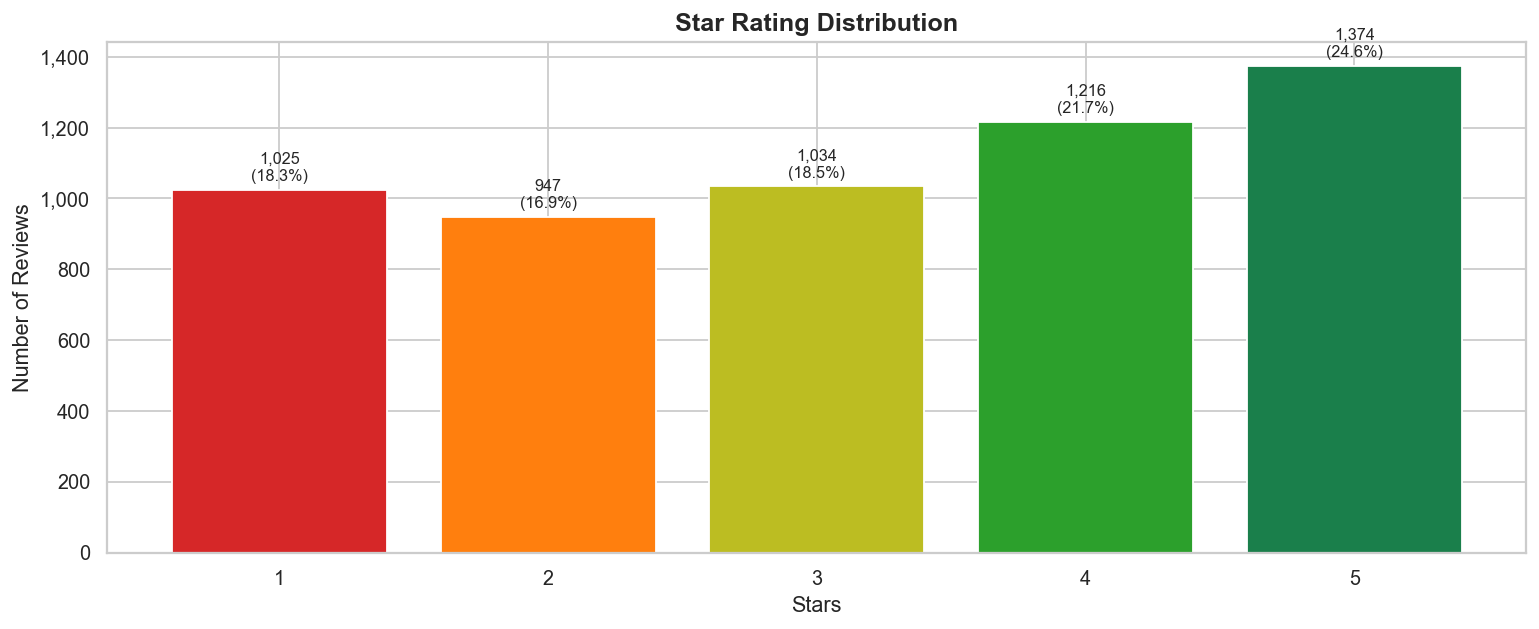

In [12]:
eda.plot_star_distribution(df_feat)

The rating distribution across the Electronics & Technology sector is
slightly more dominant on positive reviews:
- 5-star reviews leads at 24.6% (1374), followed by 4-star reviews at 21.7% (1216)
- 3-star reviews are the second most common at 18.5% (1034) closely followed by 1-star
(18.3%) and 2-star (16.9%). 

This pattern is characteristic not only of the electronics market,
post-purchase issues (faulty products, delivery failures) generate
strong negative reactions, beign 1-star reviews more common than 2-star reviews. While smooth transactions and good quality of the product generate strong
praise making 4/5-star reviews more common than 3. 

### **1.2 Top & Bottom 10 Companies by Avg Stars**

In [13]:
stats

,avg_stars,pct_positive,pct_neutral,pct_negative,avg_review_words,avg_title_words,review_word_count,wc_positive,wc_neutral,wc_negative,review_count
company,,,,,,,,,,,
brokenfones.com,5.00,100.00,0.00,0.00,33.40,5.00,33.40,33.40,0.00,0.00,20
licensel.com,4.86,100.00,0.00,0.00,14.64,3.55,14.64,14.64,0.00,0.00,22
pcrepairscheshire.co.uk,4.83,100.00,0.00,0.00,40.04,3.92,40.04,40.04,0.00,0.00,24
wildviewcameras.co.uk,4.77,100.00,0.00,0.00,39.88,3.92,39.88,39.88,0.00,0.00,26
techformusic.co.uk,4.67,100.00,0.00,0.00,41.60,4.20,41.60,41.60,0.00,0.00,30
...,...,...,...,...,...,...,...,...,...,...,...
www.richersounds.com,3.00,40.00,20.00,40.00,78.02,6.08,78.02,67.88,80.65,86.85,100
www.yourspares.co.uk,3.00,40.40,19.19,40.40,47.59,5.20,47.59,32.15,63.84,55.30,99
juicebitz.co.uk,2.99,39.39,20.20,40.40,66.17,5.67,66.17,47.05,82.60,76.60,99


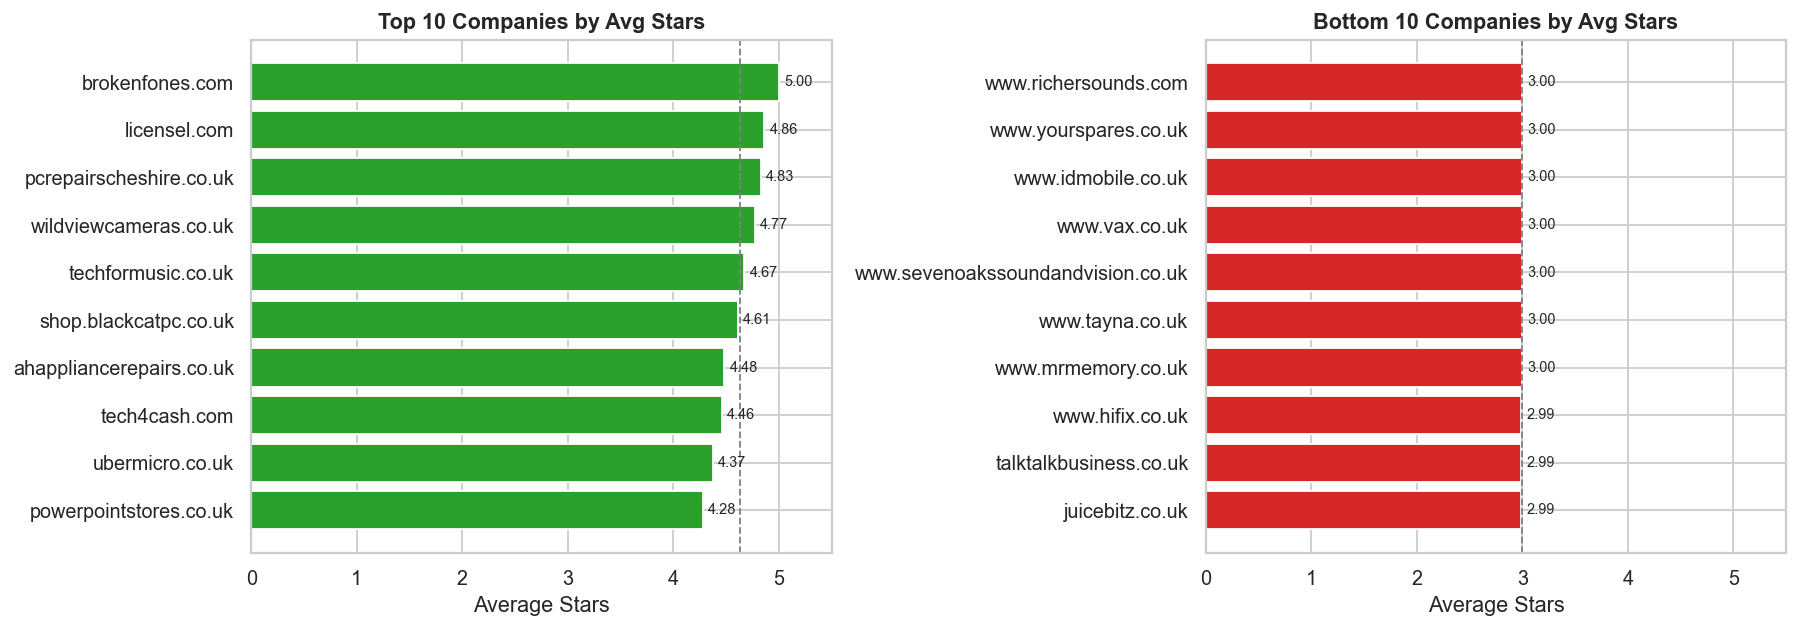

In [14]:
eda.plot_avg_stars_per_company(stats)

The top performers are dominated by **small specialist retailers**
(brokenfones.com at 5.00, licensel.com at 4.86, pcrepairscheshire.co.uk
at 4.83), all of which likely benefit from a niche focus and personalised
service. 

The bottom 10 cluster tightly around **3.00 stars**, suggesting
a floor effect — these companies are not catastrophically bad but are
consistent, unable to differentiate themselves positively. Most of them 
are veteran companies that have more reviews than the top ones.


Notably, the gap between the best (5.00) and worst (2.99) companies is
almost 2 full stars, indicating **high performance dispersion** within
the sector. This also suggest that really bad companies (1-2 star rate),
tend to disappear due to high market competitivity.

### **1.3 Review Word Count Distribution by Sentiment**

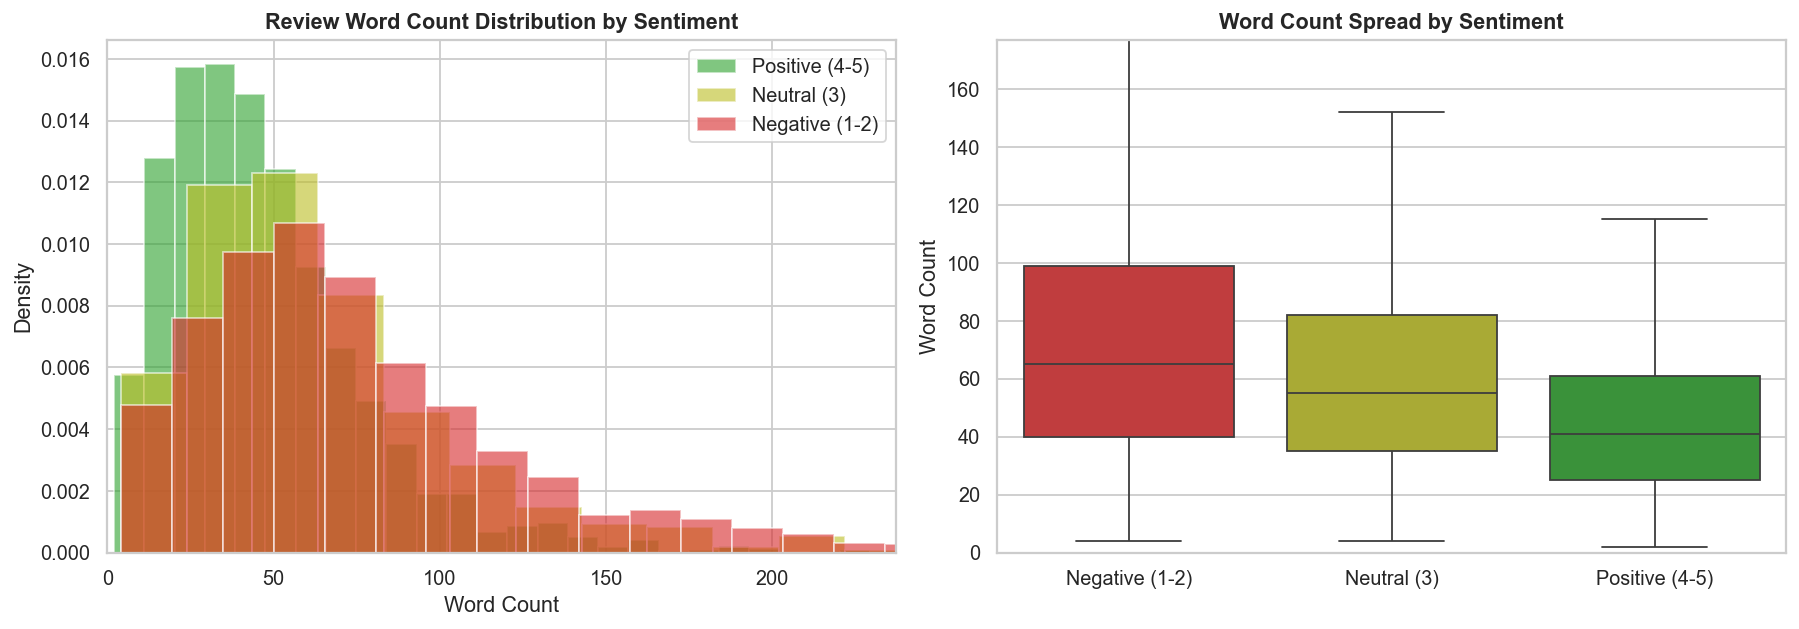

In [15]:
eda.plot_review_length_distribution(df_feat)

Negative reviewers write significantly **longer reviews** than positive
ones. The box plot makes this stark: negative reviews (1–2★) have a
median around 65 words and a wide IQR extending to ~100 words, while
positive reviews (4–5★) cluster below 60 words with a much tighter
spread. This is a well-known behavioural pattern, dissatisfied
customers feel compelled to explain and justify their complaint in
detail, while happy customers often leave short confirmatory reviews
("great service, fast delivery"). For NLP purposes, this means
**negative reviews carry richer topic signal** and are worth analysing
in more depth.

### **1.4 Top 15 Companies by Avg Review Word Count**

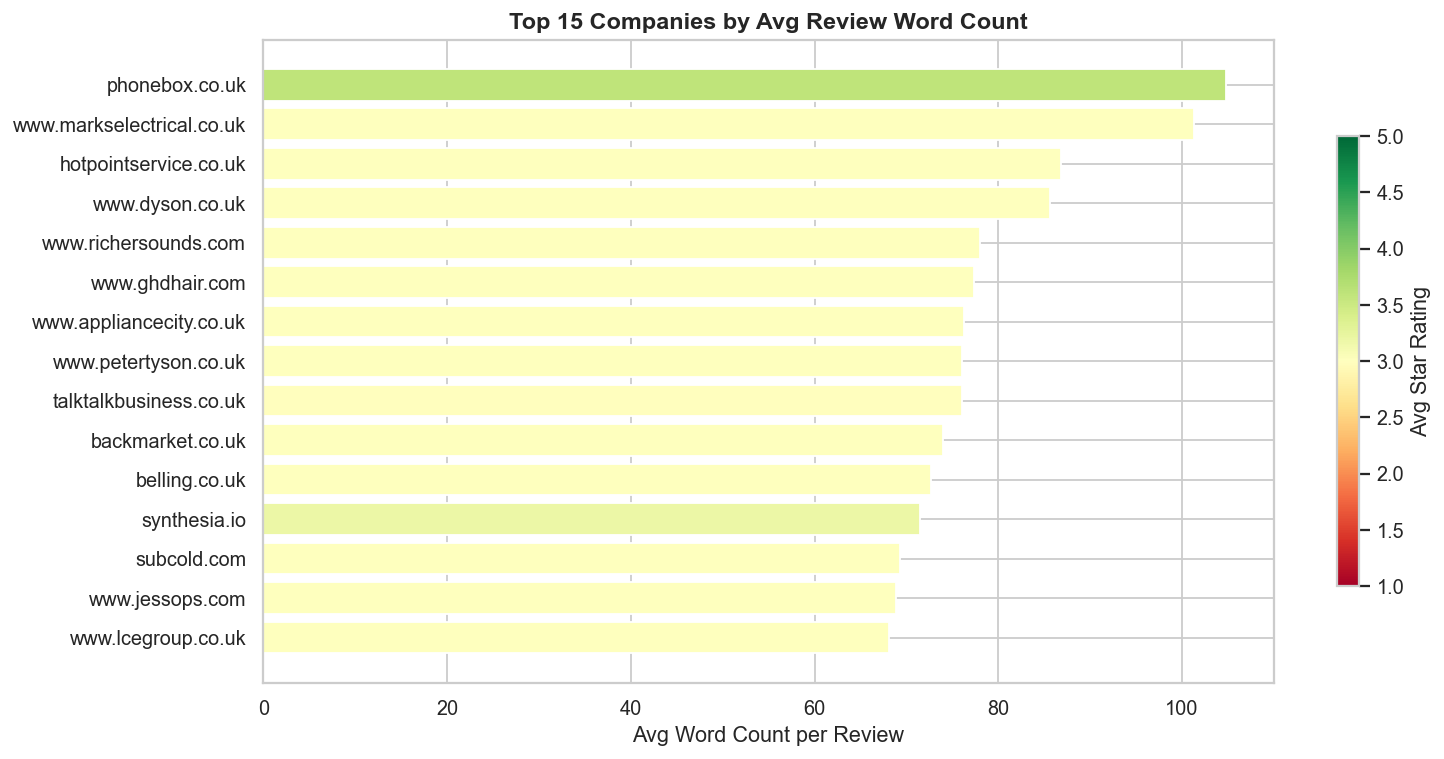

In [16]:
eda.plot_avg_review_length_per_company(stats)

Companies with the longest reviews tend to cluster around **3.0–3.5
average stars** (yellow- light green on the colour scale), confirming the
sentiment–length relationship at company level, longer reviews on average tend to mean worst stars on average.
phonebox.co.uk leads at ~105 words per review and sits in the 3.5 star range, suggesting
its customers are engaged but divided. electricalworld.com does not appear in
this top 15, suggesting its reviews are **shorter than sector average**,
which will be confirmed in the positioning analysis.

### **1.5 Company Summary Table (heatmap)**

In [17]:
display(eda.display_company_summary(stats))

,review_count,avg_stars,pct_positive,pct_negative,avg_review_words,avg_title_words
company,,,,,,
brokenfones.com,20,5.00,100.0%,0.0%,33,5
licensel.com,22,4.86,100.0%,0.0%,15,4
pcrepairscheshire.co.uk,24,4.83,100.0%,0.0%,40,4
wildviewcameras.co.uk,26,4.77,100.0%,0.0%,40,4
techformusic.co.uk,30,4.67,100.0%,0.0%,42,4
shop.blackcatpc.co.uk,28,4.61,92.9%,3.6%,45,5
ahappliancerepairs.co.uk,29,4.48,89.7%,6.9%,34,4
tech4cash.com,28,4.46,89.3%,7.1%,48,6
ubermicro.co.uk,30,4.37,90.0%,10.0%,39,4


The heatmap reveals a clean **bifurcation** in the sector: companies
in the top half (brokenfones, licensel, pcrepairscheshire) achieve
near-100% positive rates with 0% negative, while the bottom half
(phonebox, computerangels, scgconnected) see positive rates drop to
55–65% with negative rates climbing to 19–26%. The avg_review_words
column reinforces the earlier finding: phonebox.co.uk's 105-word
average is the highest in the table and coincides with its 26% negative
rate — its customers have a lot to complain about. electricalworld.com
is not visible in this top-20 slice, which foreshadows its low
percentile positioning.
Also this table confirms that top positioned companies are more recent companies
due to the lower review count.

## **2. Competitive Positioning — electricalworld.com**

Now let's study where's our target company positioned

In [18]:
stats = stats.reset_index()
print(f"\n{'='*55}")
print(f"  COMPETITIVE POSITIONING — {TARGET}")
print(f"  Category : {CAT}")
print(f"  Companies: {stats['company'].nunique()}")
print(f"{'='*55}\n")

df_clean.loc[df_clean['company']==TARGET, 'description'].unique()



  COMPETITIVE POSITIONING — electricalworld.com
  Category : Electronics & Technology
  Companies: 69



<ArrowStringArray>
['Now with over 16,000 Reviews on Reviews.io, Electrical World was founded from humble beginnings by Managing Director John Coalter an experienced electrician who began his career as a businessman at the age of 20, when he launched his first electrical contract company. We now offer worldwide delivery and have a vast range of DIY and B2B products available at extremely competitive prices!']
Length: 1, dtype: str

### **2.1 Avg Star Rating Distribution (KDE)**

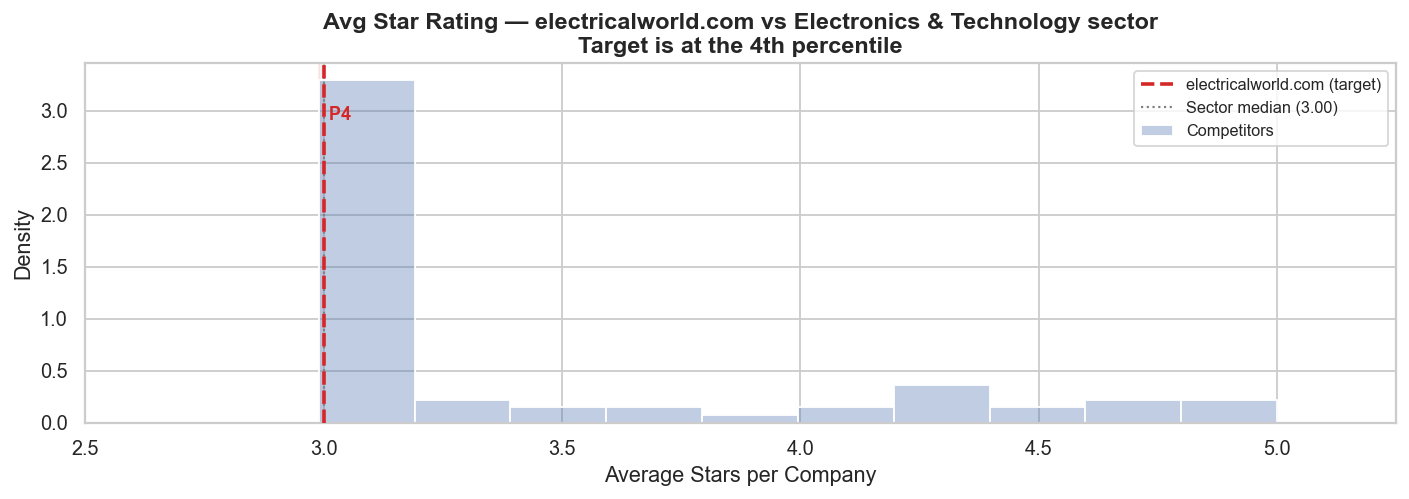

  ► electricalworld.com avg stars: 3.00  |  Sector median: 3.00  |  Percentile: 4th


In [19]:
eda.plot_stars_positioning(stats, CAT, TARGET)

``electricalworld.com`` sits at the **4th percentile** with an average of slighlty more than
3.00 stars — at the very bottom of the sector distribution. Most competitors cluster between 3-3.25, meaning our
company is located at, more or less the median. The distribution is right-skewed with a long tail of high performers,
pulling the average above electricalworld.com. Although most companies are close in ratings, in practical terms,
**96% of competitors in this sector have a higher average rating**.
This is a signal that there is a lot of room for improvement.

### **2.2 Sentiment Split vs Benchmarks**

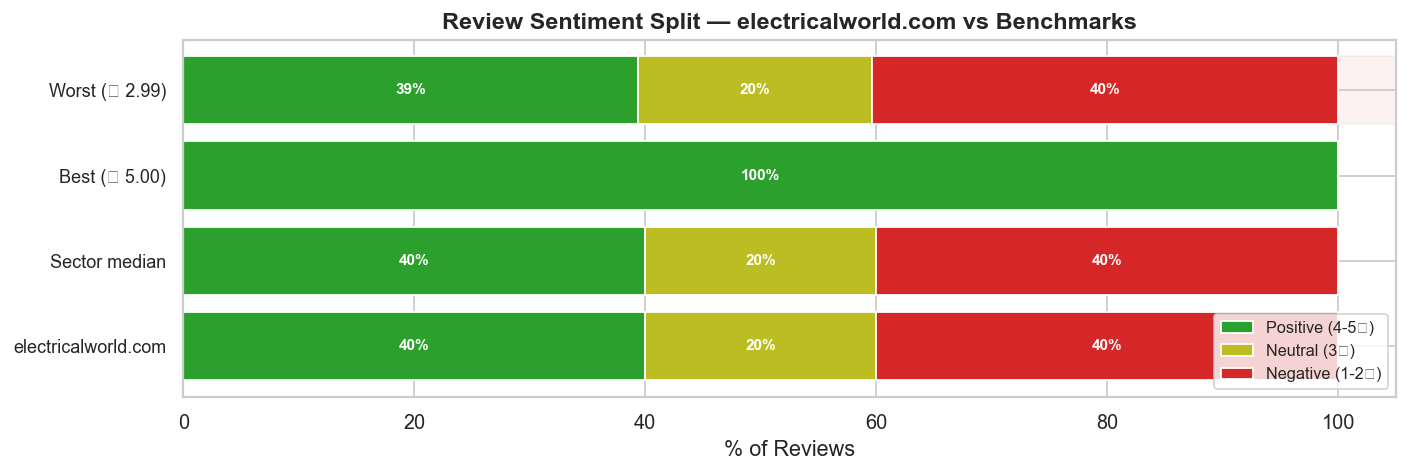

In [20]:
eda.plot_sentiment_pct_comparison(stats, TARGET)

The stacked bar chart tells a direct story. electricalworld.com has
**40% positive and 40% negative reviews** — a perfectly split, deeply
polarised customer base. This compares unfavourably to:
- The **sector median**: exactly the same as electricalworld
- The **best company**: 100% positive, 0% negative
- Even the **worst company** (★2.99): 40% positive, 41% negative —
  essentially identical to electricalworld.com

The fact that electricalworld.com matches the *worst-performing
company* in the sector on both positive and negative rates is the
clearest possible summary of its competitive position. The 20% neutral
block is average, offering no differentiation. **There is no meaningful
positive base to build on without first addressing the negative reviews.**

### **2.3 Percentile Dashboard (3 KPIs)**

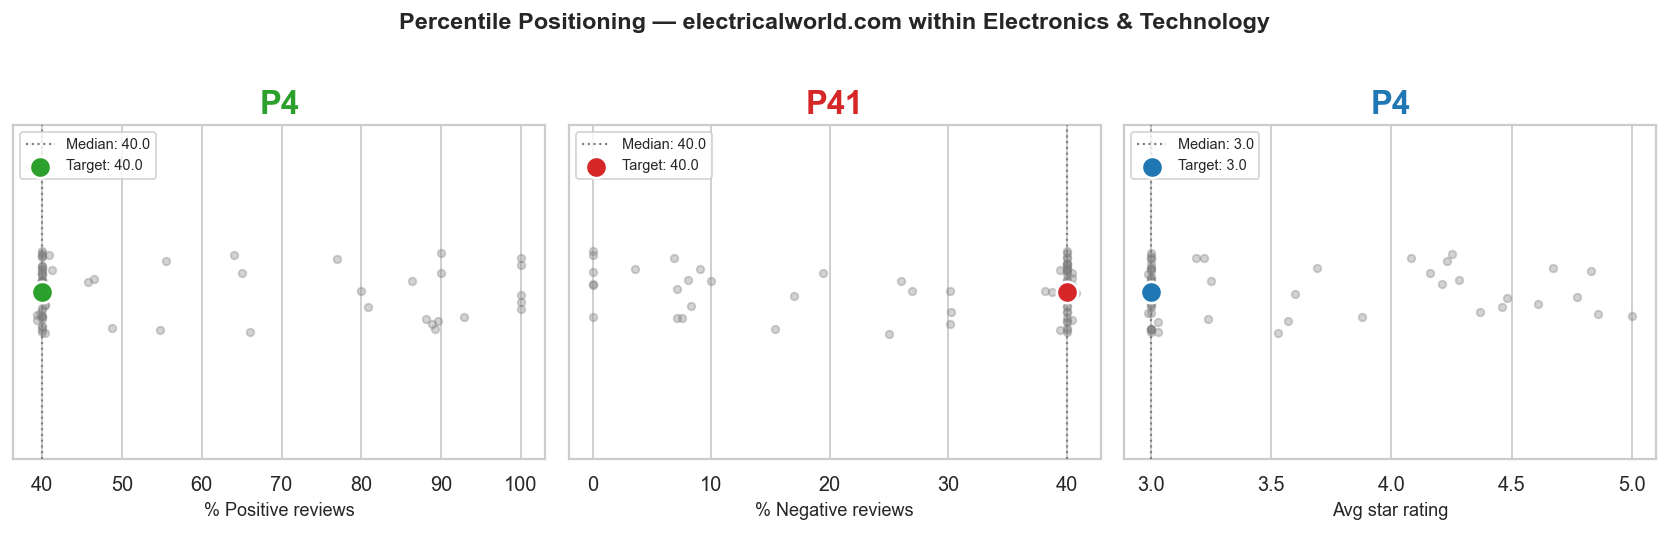

In [21]:
eda.plot_percentile_dashboard(stats, CAT, TARGET)

Three KPIs consolidate the positioning picture:

| KPI | Value | Percentile |
|-----|-------|------------|
| % Positive reviews | 40% | **P4** |
| % Negative reviews | 40% | **P41** |
| Avg star rating | 3.00 | **P4** |

The P41 on negative reviews is actually the *least* alarming figure —
being at the 41st percentile for negative rate means the company is
slightly below the median on that metric, which sounds counterintuitive
given the 40% negative rate. This reflects that many competitors also
have significant negative volumes. The real problem is the **P4 on
positive reviews**: only 4% of competitors have fewer positive reviews,
meaning electricalworld.com is almost uniquely bad at generating
satisfied customers.

### **2.4 Word Count by Sentiment vs Sector**

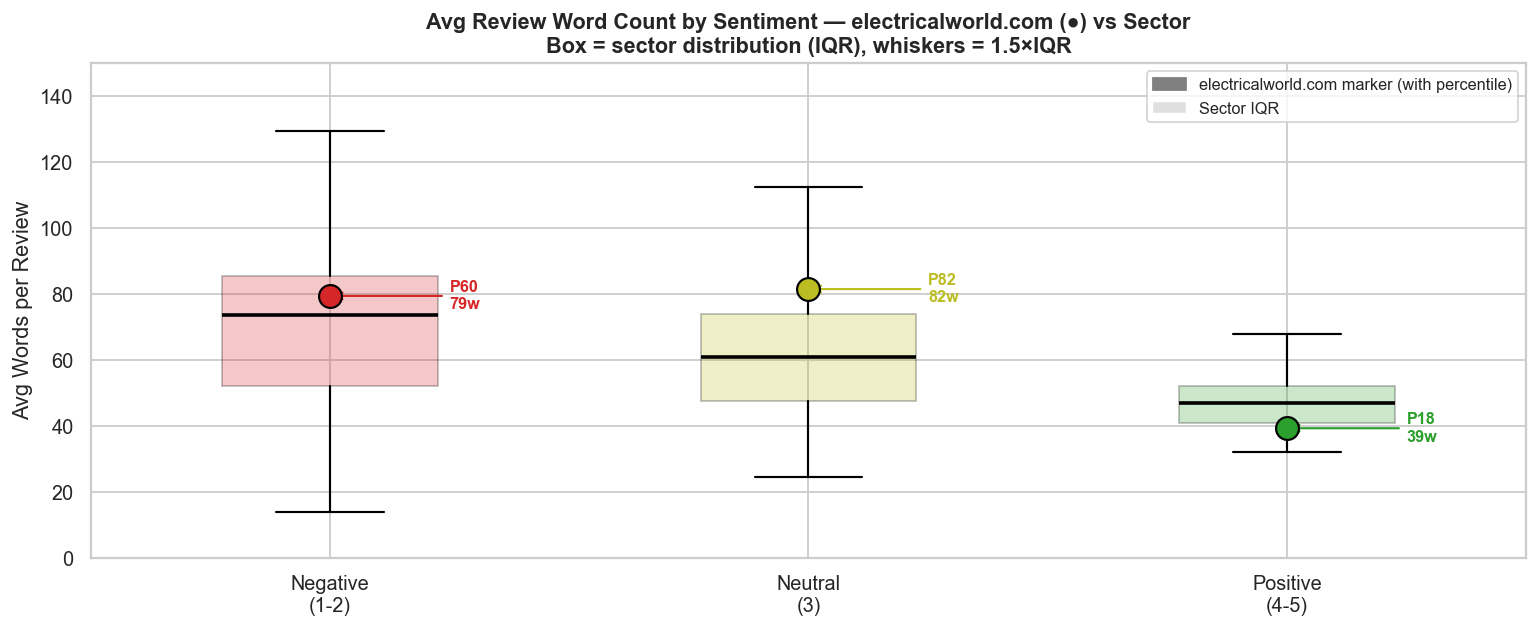

In [22]:
eda.plot_word_count_by_sentiment(stats, TARGET)

electricalworld.com's reviewers show a striking pattern:

| Sentiment | Our avg words | Sector IQR | Percentile |
|-----------|--------------|------------|------------|
| Negative | 79w | ~55–100w | **P56** |
| Neutral | 82w | ~40–80w | **P81** |
| Positive | 39w | ~25–60w | **P18** |

Negative and neutral reviewers write **more than sector average**
(P56 and P81 respectively), confirming that dissatisfied customers
are verbose and detailed in their complaints. Positive reviewers
write much less than competitors' happy customers (P18, only 39 words)
— suggesting that the small share of satisfied customers leave
**thin, unconvincing praise** that carries little weight. This imbalance
matters for reputation: long negative reviews are more persuasive to
prospective buyers than short positive ones.

## **3. NLP Topic Analysis**



2026-04-17 16:38:36,185 [INFO] No device provided, using cpu



[1/6] Splitting dataset ...
  Target 'electricalworld.com': 100 reviews
  Competitors (68 companies): 5496 reviews

[2/6] Loading SBERT and embedding reviews ...


2026-04-17 16:38:36,953 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-04-17 16:38:36,966 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-04-17 16:38:37,095 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-04-17 16:38:37,108 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-04-17 16:38:37,115 [INFO] Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
2026-04-17 16:38:37,235 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-tran

  ✓ Competitor embeddings : (5496, 384)
  ✓ Target embeddings     : (100, 384)

[3/6] Fitting BERTopic on competitors ...


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x000002AC533A1F80>
Traceback (most recent call last):
  File "c:\Users\HP\Desktop\Master\7. DL\.venv\Lib\site-packages\llvmlite\binding\executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 
2026-04-17 16:41:05,736 - BERTopic - Dimensionality - Completed ✓
2026-04-17 16:41:05,736 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 16:41:06,099 - BERTopic - Cluster - Completed ✓
2026-04-17 16:41:06,114 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-17 16:41:20,554 - BERTopic - Representation - Completed ✓
2026-04-17 16:41:21,703 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.


...

  ✓ Sentiment distribution:
      negative  : 54.0%
      positive  : 40.0%
      neutral   : 6.0%

  Running sentiment on competitors ...
  Loading sentiment model 'cardiffnlp/twitter-roberta-base-sentiment-latest' ...


2026-04-17 16:42:13,588 [INFO] HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-17 16:42:13,588 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment-latest/3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7/config.json "HTTP/1.1 200 OK"
2026-04-17 16:42:13,733 [INFO] HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11975.55it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  |

  Running sentiment on 5,496 reviews ...


2026-04-17 16:42:14,659 [INFO] HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/refs%2Fpr%2F43/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-17 16:42:14,860 [INFO] HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/refs%2Fpr%2F43/model.safetensors "HTTP/1.1 302 Found"


  ✓ Sentiment distribution:
      negative  : 48.1%
      positive  : 39.8%
      neutral   : 12.2%

[6/6] Assembling result DataFrames ...

[1/5] Assigning macro topics ...

  Macro topic distribution in electricalworld.com:
macro_topic
General / Other                     73
Delivery & Shipping                 19
Order & Purchase Process             5
Returns, Refunds & Cancellations     2
Product Quality & Condition          1

[2/5] Macro topic distribution plots ...


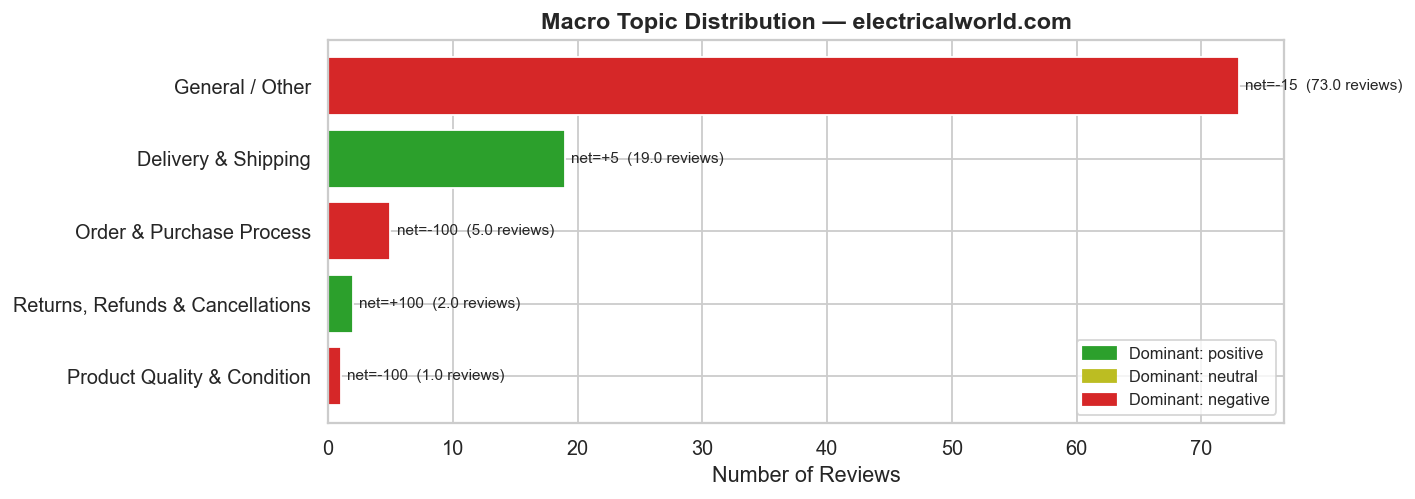

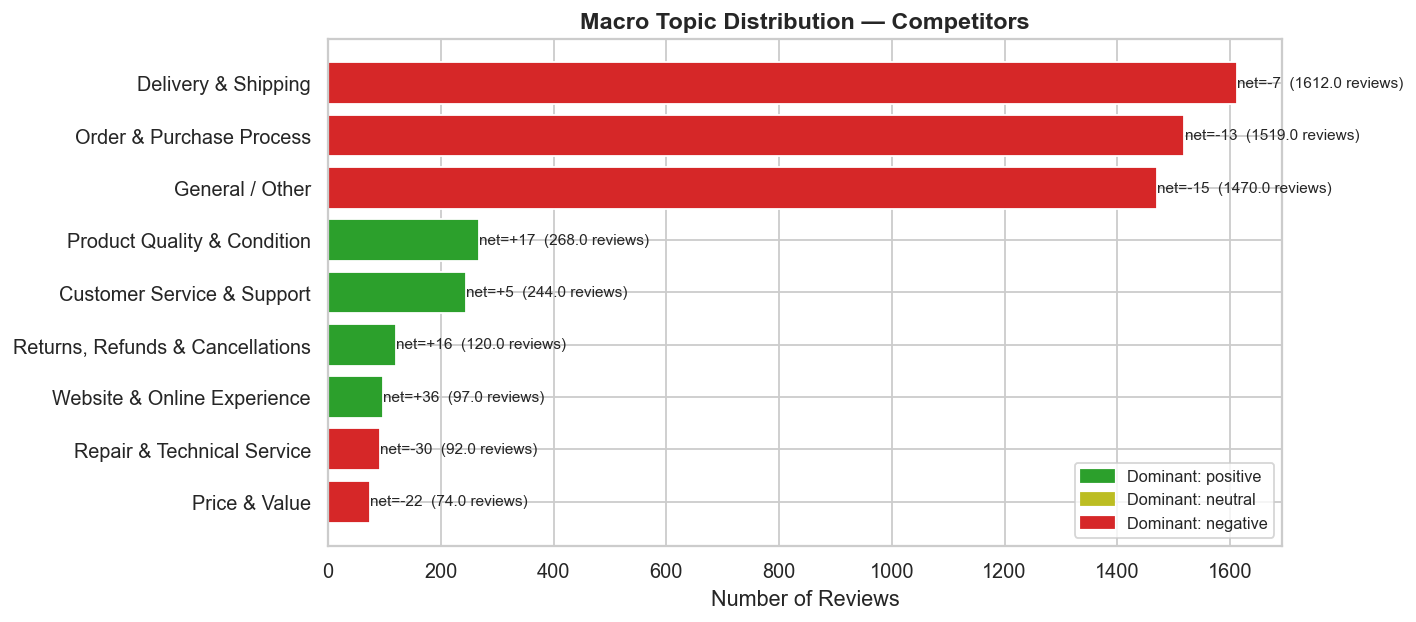


[3/5] Macro sentiment heatmaps ...


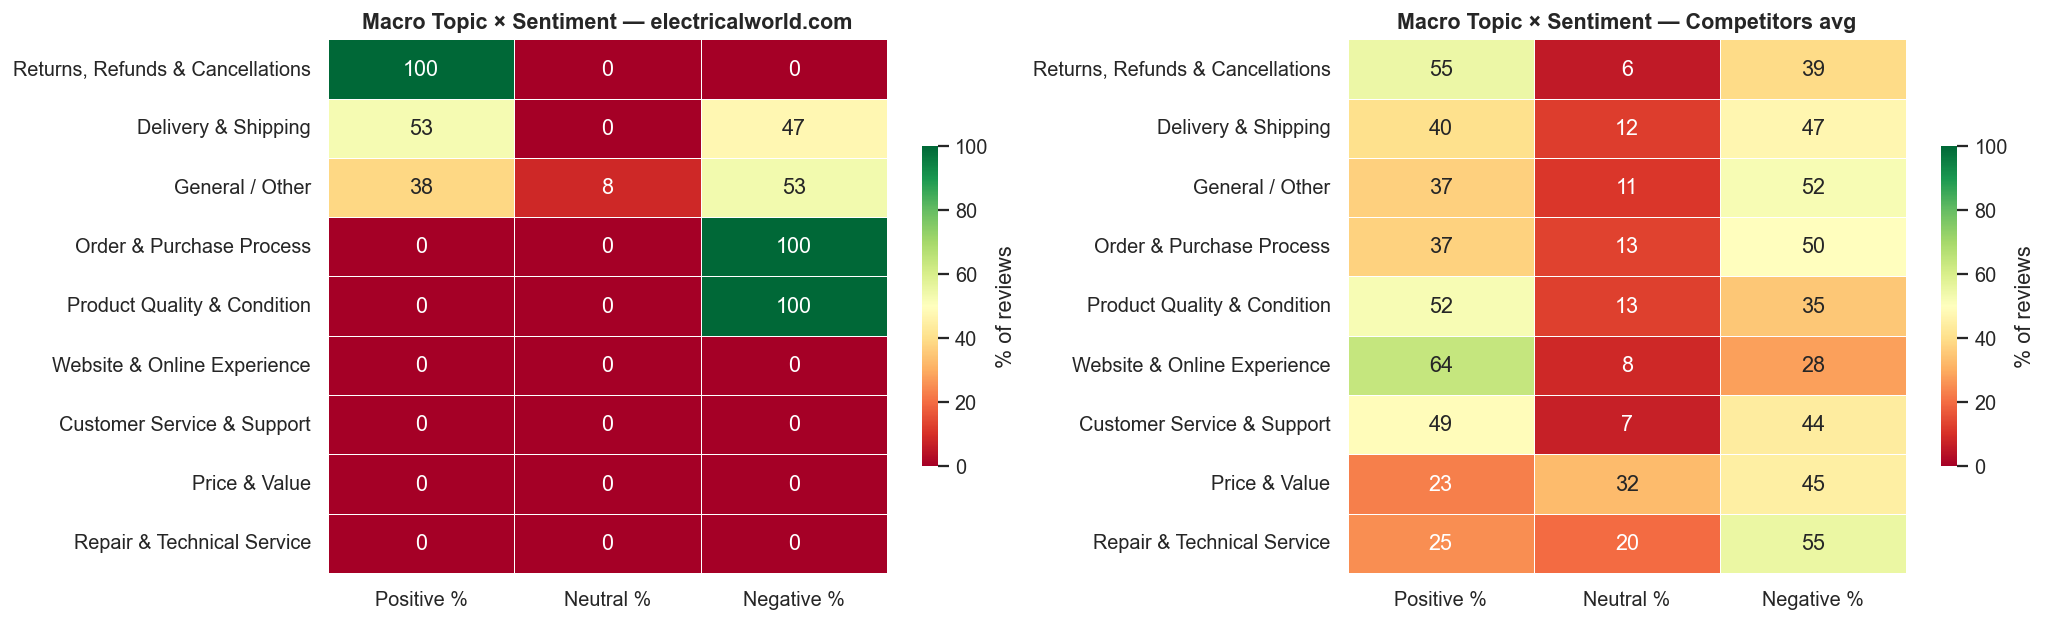


[4/5] Head-to-head net sentiment ...


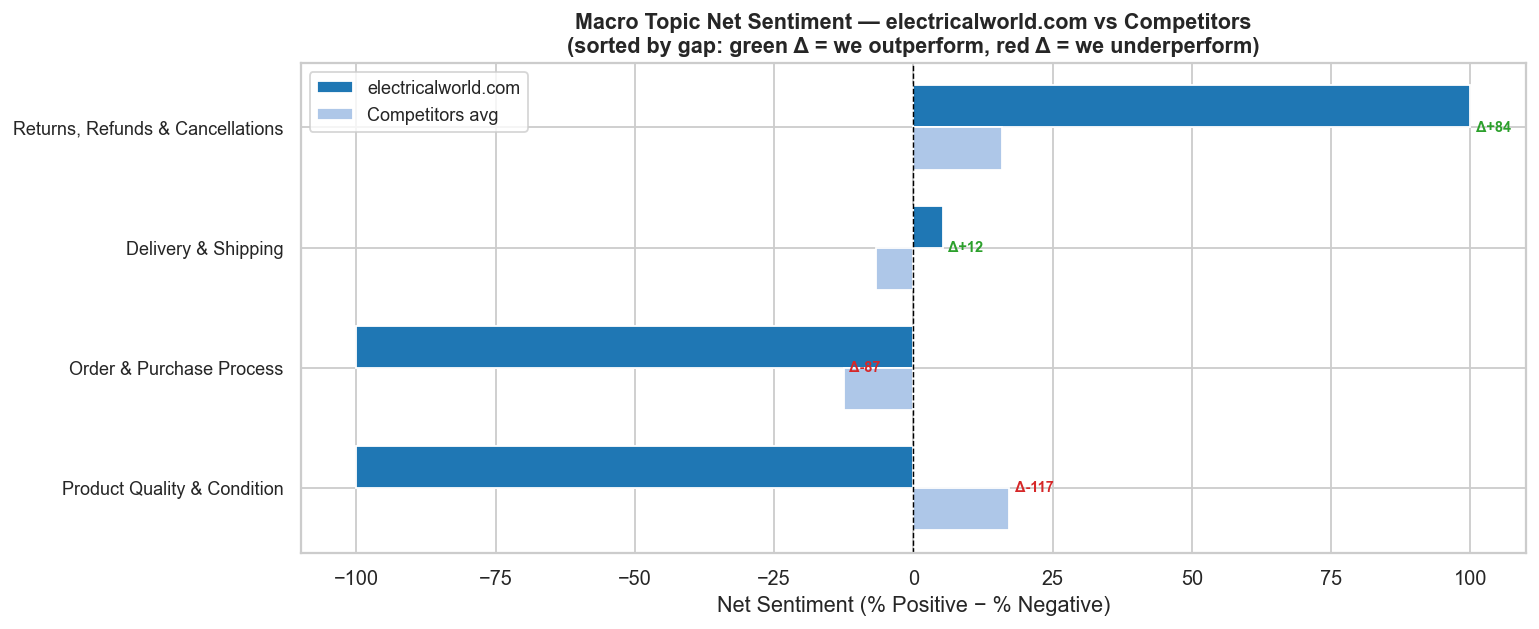


  MACRO STRENGTHS — electricalworld.com outperforms competitors
  ✅  Returns, Refunds & Cancellations          net=+100  gap=+84
  ✅  Delivery & Shipping                       net=+5  gap=+12

  MACRO WEAKNESSES — electricalworld.com underperforms competitors
  ⚠️   Product Quality & Condition               net=-100  gap=-117
  ⚠️   Order & Purchase Process                  net=-100  gap=-87

  PRIORITY IMPROVEMENT AREAS (lowest net sentiment in target)
  🔴  Product Quality & Condition               net=-100
  🔴  Order & Purchase Process                  net=-100
  🟢  Delivery & Shipping                       net=+5
  🟢  Returns, Refunds & Cancellations          net=+100

[5/5] Root cause extraction (gap threshold = -5.0) ...

█████████████████████████████████████████████████████████████████
  ROOT CAUSE — Product Quality & Condition
█████████████████████████████████████████████████████████████████
  electricalworld.com net sentiment : -100
  Competitors net sentiment   : +17
  Gap   

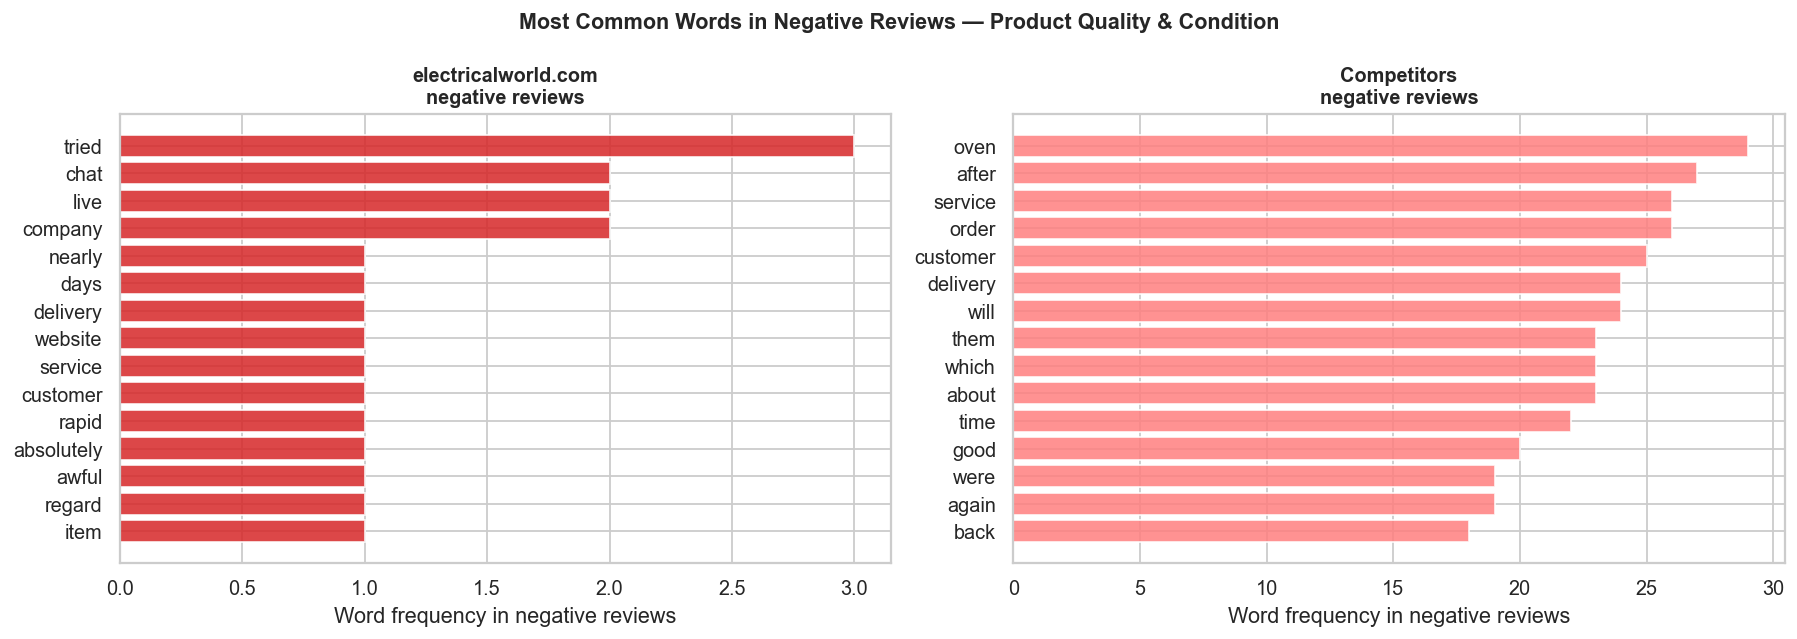


█████████████████████████████████████████████████████████████████
  ROOT CAUSE — Order & Purchase Process
█████████████████████████████████████████████████████████████████
  electricalworld.com net sentiment : -100
  Competitors net sentiment   : -13
  Gap                         : -87  (we underperform)

  Granular sub-topics in this macro category:
    🔴  T15: customer service, item purchased, want refund, customer  n=  4   neg=100%
    🔴  T14: ordered wrong, refunded, spoke customer, customer   n=  1   neg=100%

  Most negative reviews (5 total negative, showing 5):

  [1] ★☆☆☆☆  |  The worst seller i come across
  Sub-topic : T15: customer service, item purchased, want refund, customer
  Review    : The worst seller i have ever come across, you phone them you can't get hold of them, you chat online but they are all automated, you can't get an agent and when you email them you may or may not get a reply but when you do then that is a day after absolutely disgusting seller.I placed 

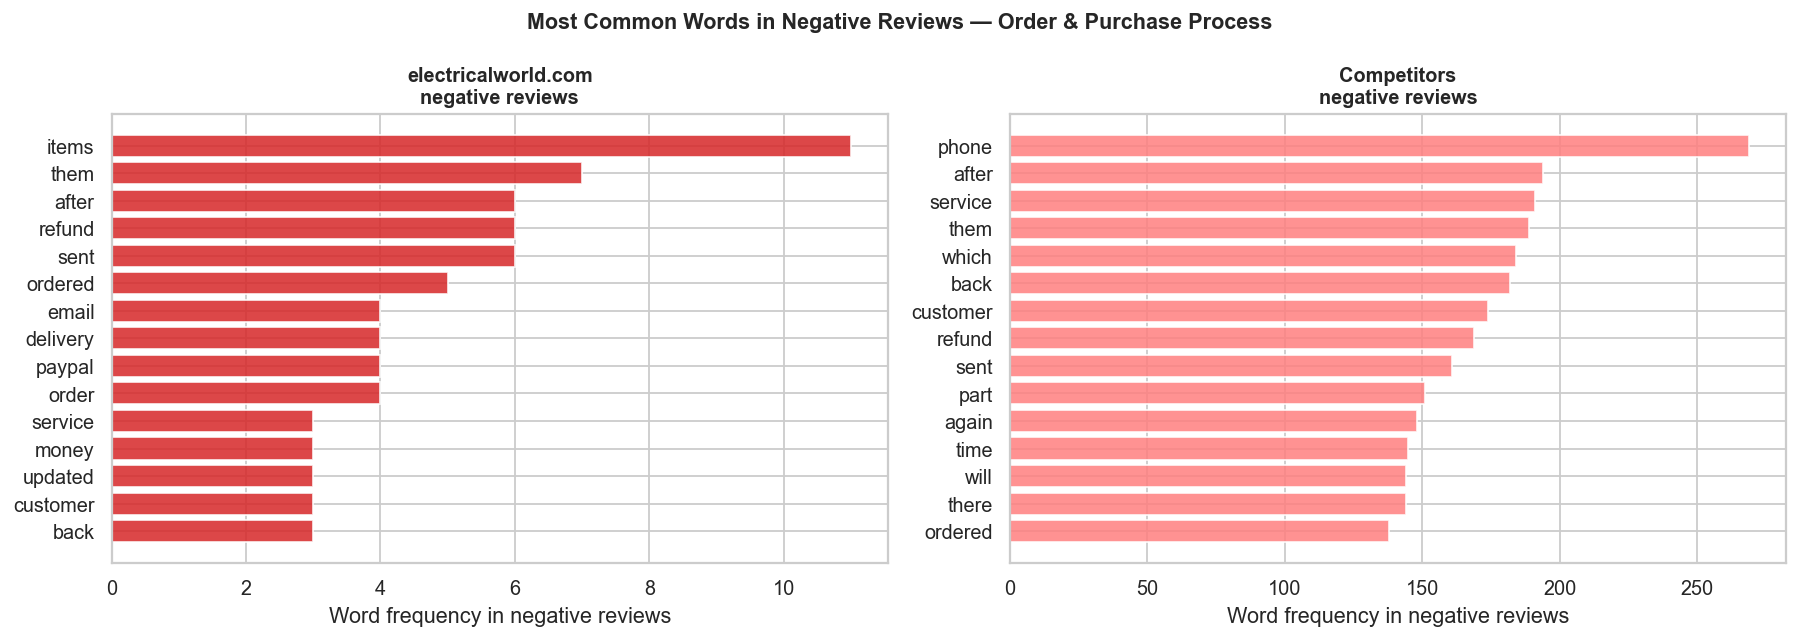

 1 negative reviews found
 5 negative reviews found


In [23]:
# ── Step 1: run the existing granular NLP pipeline ────────────────────
df_target_full, df_comp_full, topic_model = nlp.run_nlp_pipeline(df_clean, target=TARGET)

# ── Step 2: macro topic analysis + root cause ────────────────────────
macro_results = nlp.run_macro_analysis(
    df_target_full=df_target_full,
    df_comp_full=df_comp_full,
    target_name=TARGET,
    min_gap=-5.0,          # flag topics where we underperform by >5 pts
    max_reviews_shown=5    # raw reviews shown per weak topic
)

# ── Step 4: inspect specific weak topic reviews ───────────────────────
# Access the full DataFrame of negative reviews for any weak macro topic
neg = macro_results['negative_reviews']

# Example: inspect all negative reviews for Returns & Refunds
if "Returns, Refunds & Cancellations" in neg:
    display(neg["Returns, Refunds & Cancellations"])

# Export all negative reviews to Excel for further manual review
for macro_topic, df_neg in neg.items():
    safe_name = macro_topic.replace('/', '-').replace(' ', '_')
    # df_neg.to_excel(f"negative_reviews_{safe_name}.xlsx", index=False)
    print(f" {len(df_neg)} negative reviews found")

# ── Step 5: optional BERTopic interactive plots ───────────────────────
import plotly.io as pio
pio.renderers.default = "vscode"
topic_model.visualize_topics()
topic_model.visualize_barchart()